In [13]:
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

In [14]:
data_path = "/home/riccardo/Documents/orbit/source/standalone/logs/rsl_rl/unitree_go1_jump/"

In [18]:
# results = data_path +"_test.bin"
results = data_path +"test.bin"

In [19]:
data = joblib.load(results)

In [20]:
data

array([[[ 0.8371811 , -0.10973358,  0.40000004],
        [ 0.39820862, -0.18431854,  0.40000004],
        [ 0.9464798 ,  0.20948029,  0.40000004],
        ...,
        [ 0.8351898 , -0.02980042,  0.40000004],
        [ 0.5916748 ,  0.20092773,  0.40000004],
        [ 0.8189087 , -0.16841125,  0.40000004]],

       [[ 0.64956665, -0.0399704 ,  0.4000018 ],
        [ 0.40777588, -0.15692902,  0.39999846],
        [ 0.66324615,  0.03746033,  0.40000072],
        ...,
        [ 0.6374283 , -0.01477051,  0.40000024],
        [ 0.47779083,  0.09667969,  0.40000162],
        [ 0.6228714 , -0.09173584,  0.3999993 ]]], dtype=float32)

In [21]:
data.shape

(2, 4096, 3)

In [22]:
des = data[0][:,:2]
des.shape

(4096, 2)

In [23]:
des = data[0][:, :2][(abs(data[0][:, 1]) < 0.3) & (data[0][:, 0] >= 0)]
des.shape

(4096, 2)

In [24]:
actual = data[1][:,:2]
actual.shape

(4096, 2)

In [25]:
actual = data[1][:, :2][(abs(data[0][:, 1]) < 0.3) & (data[0][:, 0] >= 0)]
actual.shape

(4096, 2)

In [26]:
err = np.linalg.norm(des - actual, axis=1)
err

array([0.20016514, 0.02901239, 0.33137918, ..., 0.19833185, 0.15439305,
       0.21049878], dtype=float32)

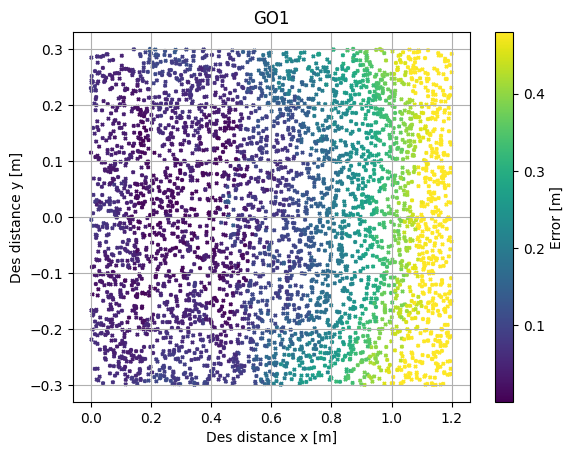

In [45]:
# plt.figure(figsize=(8,10))
plt.scatter(des[:,0],des[:,1], np.full(des[: , 1].shape,5), vmax=0.48, marker='x', c=err)
plt.grid()
plt.title("GO1")
plt.colorbar(label="Error [m]")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path+"abs_err.pdf")
plt.show()

In [46]:
des_dist = np.linalg.norm(des, axis=1)
des_dist

array([0.8443421 , 0.4387977 , 0.9693844 , ..., 0.83572125, 0.6248608 ,
       0.8360465 ], dtype=float32)

In [47]:
actual_dist = np.linalg.norm(actual, axis=1)
actual_dist

array([0.6507953 , 0.43693006, 0.6643032 , ..., 0.6375994 , 0.48747414,
       0.6295905 ], dtype=float32)

In [48]:
np.linalg.norm([0.6,.3])

0.6708203932499369

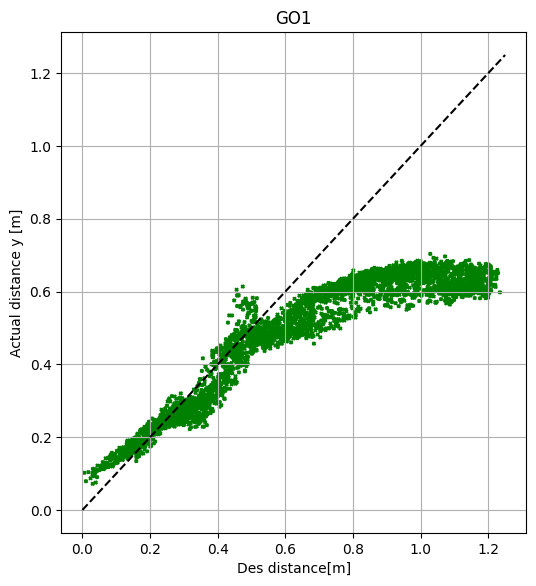

In [57]:

plt.figure(figsize=(6, 6.5))
plt.grid()
plt.scatter(des_dist,actual_dist, np.full(des[: , 1].shape,5), marker='x', alpha=1, color="green")
plt.title("GO1")
plt.plot([0.0,1.25],[0.0,1.25], '--', color="black")
# plt.colorbar(label="Error [m]")
plt.xlabel("Des distance[m]")
plt.ylabel("Actual distance y [m]")
plt.savefig(data_path+"diag_err.pdf")
plt.show()

In [23]:
perc_err = err / des_dist
perc_err

array([0.44009128, 0.12886661, 0.318325  , ..., 0.3655054 , 0.11494835,
       0.44371155], dtype=float32)

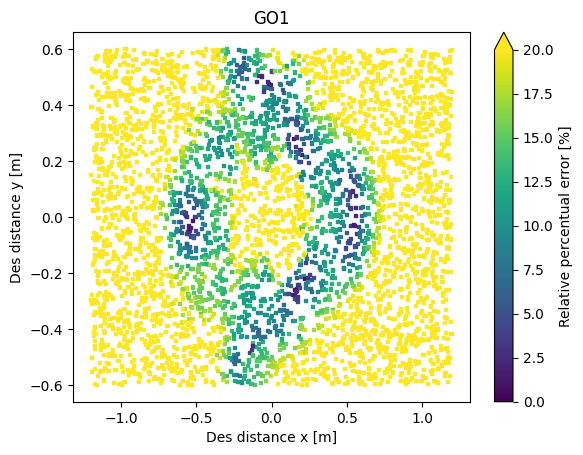

In [24]:
plt.scatter(des[:,0],des[:,1], np.full(des[: , 1].shape,5), marker='s', c=perc_err*100, vmin=0, vmax=20)
plt.colorbar(label="Relative percentual error [%]", extend='max')
plt.title("GO1")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path+"perc_err.pdf")
plt.show()

In [23]:
data_path = "/home/riccardo/Documents/orbit/source/standalone/logs/rsl_rl/unitree_a1_jump/"

In [24]:
# results = data_path +"_test.bin"
results = data_path +"test.bin"

In [25]:
data = joblib.load(results)

In [26]:
data

array([[[ 0.39749146, -0.51797485,  0.40000004],
        [ 0.22116089,  0.02984619,  0.40000004],
        [-0.4825592 ,  0.15150452,  0.40000004],
        ...,
        [-0.05310059,  0.5700226 ,  0.40000004],
        [ 0.521698  ,  0.28494263,  0.40000004],
        [-0.57450867,  0.2989807 ,  0.40000004]],

       [[ 0.35873413, -0.4548645 ,  0.39998248],
        [ 0.23982239,  0.02151489,  0.39999148],
        [-0.4807129 ,  0.1053772 ,  0.40018013],
        ...,
        [-0.10890198,  0.4908905 ,  0.4177012 ],
        [ 0.50198364,  0.19966125,  0.39987013],
        [-0.5145874 ,  0.17628479,  0.40378854]]], dtype=float32)

In [27]:
data.shape

(2, 10000, 3)

In [28]:
des = data[0][:,:2]
des

array([[ 0.39749146, -0.51797485],
       [ 0.22116089,  0.02984619],
       [-0.4825592 ,  0.15150452],
       ...,
       [-0.05310059,  0.5700226 ],
       [ 0.521698  ,  0.28494263],
       [-0.57450867,  0.2989807 ]], dtype=float32)

In [29]:
actual = data[1][:,:2]
actual

array([[ 0.35873413, -0.4548645 ],
       [ 0.23982239,  0.02151489],
       [-0.4807129 ,  0.1053772 ],
       ...,
       [-0.10890198,  0.4908905 ],
       [ 0.50198364,  0.19966125],
       [-0.5145874 ,  0.17628479]], dtype=float32)

In [30]:
err = np.linalg.norm(data[0][:,:2] - data[1][:,:2], axis=1)
err

array([0.0740611 , 0.02043678, 0.04616426, ..., 0.0968281 , 0.08753038,
       0.13654613], dtype=float32)

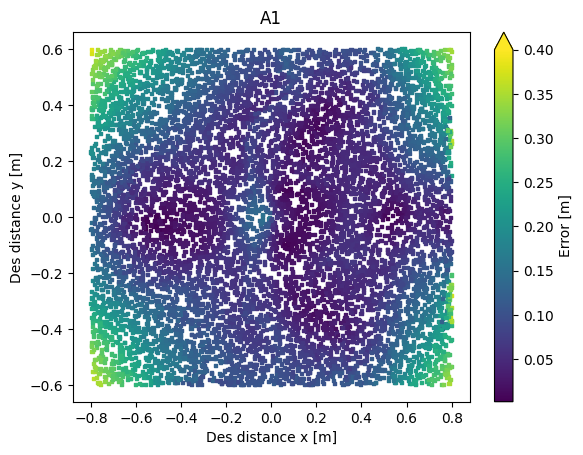

In [31]:
plt.scatter(des[:,0],des[:,1], np.full(des[: , 1].shape,5), marker='s', c=err, vmax=0.4)
plt.colorbar(label="Error [m]", extend="max")
plt.title("A1")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path+"abs_err.pdf")
plt.show()

In [32]:
#  try to interpolate data
grid_x, grid_y = np.mgrid[des[:,0].min():des[:,0].max():100j, des[:,1].min():des[:,1].max():100j]

In [33]:
from scipy.ndimage import gaussian_filter

In [34]:
grid_z = griddata(des, err, (grid_x, grid_y), method='linear')
# grid_z = gaussian_filter(grid_z, sigma=1)

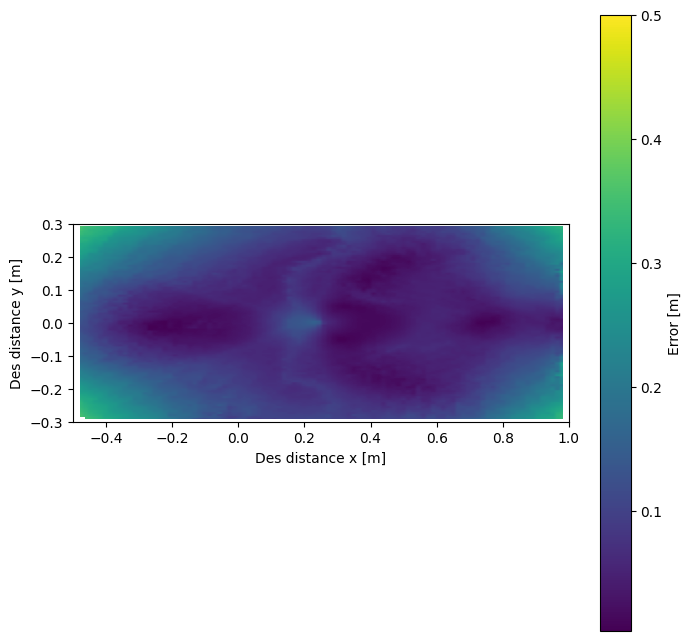

In [35]:
plt.figure(figsize=(8, 8))
plt.imshow(grid_z.T, extent=(-.5,1,-.3,.3), origin='lower', vmax=0.5)
# plt.imshow(grid_z.T, extent=(0,1,-.3,.3), origin='lower')
plt.colorbar(label="Error [m]")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path+"abs_err_interpolated.pdf")
plt.show()

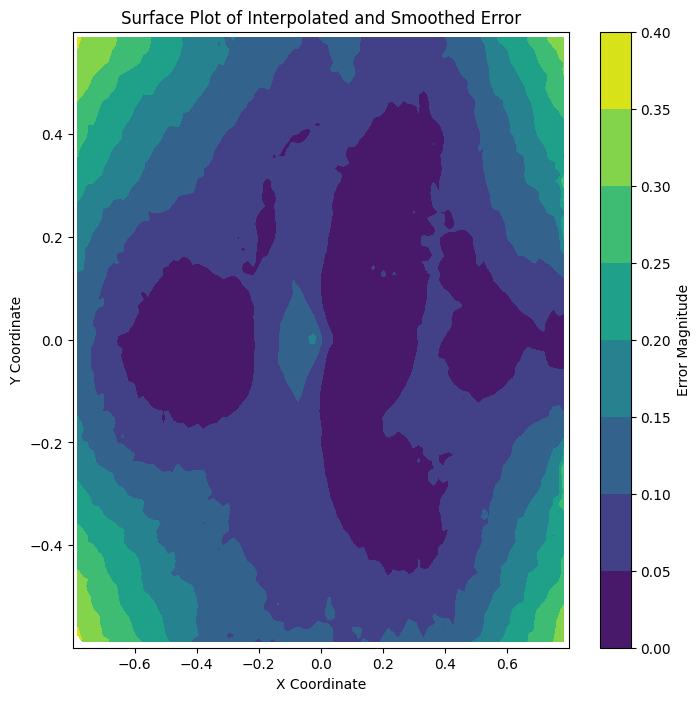

In [36]:
plt.figure(figsize=(8, 8))
plt.contourf(grid_x, grid_y, grid_z, cmap='viridis')
plt.colorbar(label='Error Magnitude')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Surface Plot of Interpolated and Smoothed Error')
plt.show()

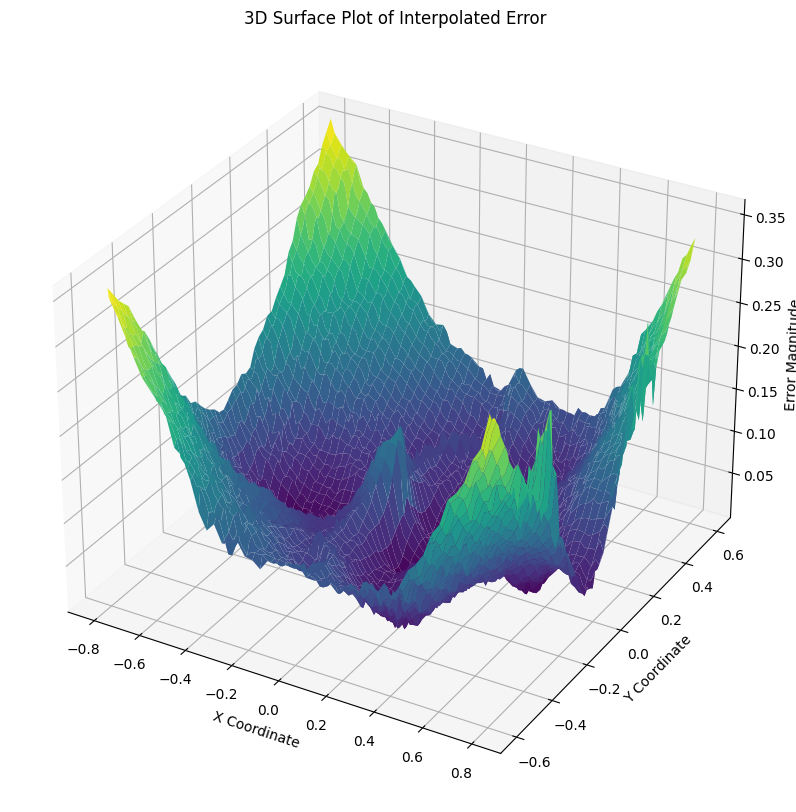

In [37]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(grid_x, grid_y, grid_z, cmap='viridis')
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
# plt.colorbar(label="Error [m]")
ax.set_zlabel('Error Magnitude')
ax.set_title('3D Surface Plot of Interpolated Error')
plt.show()


In [38]:
des_dist = np.linalg.norm(des, axis=1)
des_dist

array([0.6529145 , 0.2231657 , 0.50578356, ..., 0.5724906 , 0.5944419 ,
       0.64764935], dtype=float32)

In [39]:
actual_dist = np.linalg.norm(actual, axis=1)
actual_dist

array([0.57930297, 0.24078552, 0.49212727, ..., 0.50282514, 0.5402335 ,
       0.5439453 ], dtype=float32)

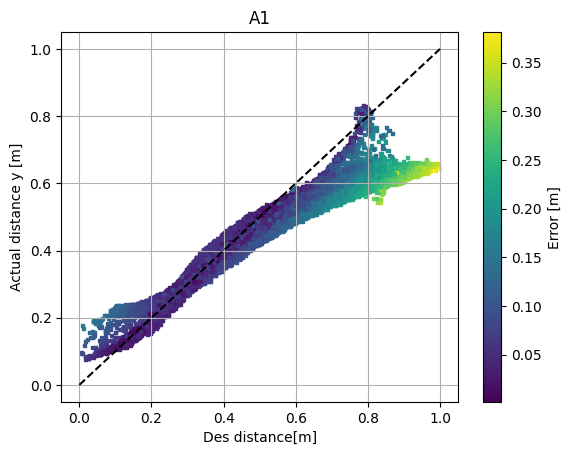

In [40]:
plt.grid()
plt.scatter(des_dist,actual_dist, np.full(des[: , 1].shape,5), marker='s', c=err, alpha=1)
plt.plot([0.0,1.],[0.0,1.], '--', color="black")
plt.title("A1")
plt.colorbar(label="Error [m]")
plt.xlabel("Des distance[m]")
plt.ylabel("Actual distance y [m]")
plt.savefig(data_path+"diag_err.pdf")
plt.show()

In [41]:
perc_err = err / des_dist
perc_err

array([0.11343154, 0.09157672, 0.09127275, ..., 0.16913484, 0.147248  ,
       0.21083343], dtype=float32)

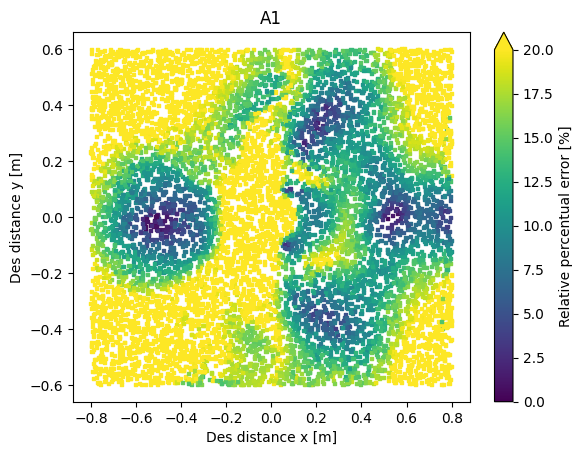

In [42]:
plt.scatter(des[:,0],des[:,1], np.full(des[: , 1].shape,5), marker='s', c=perc_err*100, vmin=0, vmax=20)
plt.colorbar(label="Relative percentual error [%]", extend='max')
plt.title("A1")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path+"perc_err.pdf")
plt.show()